In [ ]:
# https://pyimagesearch.com/2021/11/01/training-an-object-detector-from-scratch-in-pytorch/

In [25]:
# Define Imports

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision import models
from tqdm import tqdm
import pickle

# Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Set pin memory for DataLoader
PIN_MEMORY = True if DEVICE.type == 'cuda' else False

Using device: cuda


In [3]:
# Set hyperparameters
LR = 0.001  # Learning rate
BATCH_SIZE = 8  # Batch size
EPOCHS = 10  # Number of epochs


# Set ImageNet mean and std
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Set loss weights
LABEL_WEIGHTS = 1.0
BBOX_WEIGHTS = 1.0

In [4]:
# Create custom dataset class
class ValorantTensorDataset(Dataset):
    def __init__(self, tensors, transform=None):
        self.tensors = tensors
        self.transform = transform

    def __getitem__(self, index):
        # get the image, label, and bounding box tensors
        image = self.tensors[0][index]
        label = self.tensors[1][index]
        bbox = self.tensors[2][index]

        # transpose the image tensor to match the expected input shape
        image = image.permute(2, 0, 1)

        # apply transformations if specified
        if self.transform:
            image = self.transform(image)

        return (image, label, bbox)

    def __len__(self):
        return self.tensors[0].size(0)

In [5]:
train = pd.read_csv('train.csv')
train.head()

,filename,filepath,width,height,depth,label,xmin,ymin,xmax,ymax
0,img_0028,train/images/img_0028.jpg,640,640,3,Jett,292,283,384,445
1,img_1336,train/images/img_1336.jpg,640,640,3,Jett,374,292,397,366
2,img_0996,train/images/img_0996.jpg,640,640,3,Phoenix,294,304,307,349
3,img_0996,train/images/img_0996.jpg,640,640,3,Jett,250,245,267,289
4,img_2159,train/images/img_2159.jpg,640,640,3,Phoenix,94,109,281,639


In [6]:
# Preprocess dataset
data_path = "train.csv"
train_data = pd.read_csv(data_path)

# Set data lists
images = []
labels = []
bboxes = []
image_paths = []

for row in list(train_data.itertuples())[:2000]: # Limit to 2000 rows for testing
    # Read image
    image = cv2.imread(row.filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))

    # Scale bbox coordinates
    xmin = row.xmin / row.width
    xmax = row.xmax / row.width
    ymin = row.ymin / row.height
    ymax = row.ymax / row.height

    # Append data
    images.append(image)
    labels.append(row.label)
    bboxes.append((xmin, ymin, xmax, ymax))
    image_paths.append(row.filepath)

In [8]:
images = np.array(images, dtype="float32")
labels = np.array(labels)
bboxes = np.array(bboxes, dtype="float32")
image_paths = np.array(image_paths)

In [10]:
# Train and validation split
split_ratio = 0.8
train_images, val_images, train_labels, val_labels, train_bboxes, val_bboxes, train_image_paths, val_image_paths = train_test_split(
    images, labels, bboxes, image_paths, test_size=1-split_ratio, random_state=seed
)

# Encode labels
le = LabelEncoder()
labels = le.fit_transform(labels)

# Convert to tensors
train_images = torch.tensor(train_images, dtype=torch.float32)
val_images = torch.tensor(val_images, dtype=torch.float32)
train_labels = torch.tensor(train_labels)
val_labels = torch.tensor(val_labels, dtype=torch.long)
train_bboxes = torch.tensor(train_bboxes, dtype=torch.float32)
val_bboxes = torch.tensor(val_bboxes, dtype=torch.float32)

In [11]:
# Define transformations
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Create datasets
train_dataset = ValorantTensorDataset((train_images, train_labels, train_bboxes), transform=transform)
val_dataset = ValorantTensorDataset((val_images, val_labels, val_bboxes), transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=PIN_MEMORY)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data 

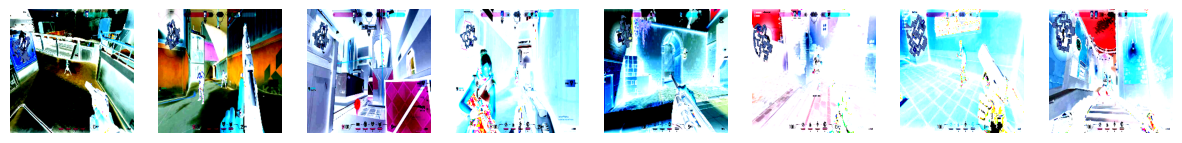

In [ ]:
# Visualize a batch of data
def visualize_batch(loader):
    images, labels, bboxes = next(iter(loader))
    images = images.permute(0, 2, 3, 1).numpy()  # Convert to HWC format for visualization

    fig, axs = plt.subplots(1, len(images), figsize=(15, 5))
    for i in range(len(images)):
        axs[i].imshow(images[i])
        # axs[i].set_title(f"Label: {labels[i].item()}\nBBox: {bboxes[i].numpy()}")
        axs[i].axis('off')
    plt.show()

visualize_batch(train_loader)

In [ ]:
# Define the model architecture

class ValorantAgentDetector(nn.Module):
    def __init__(self, base_model, num_classes):
        super(ValorantAgentDetector, self).__init__()
        self.base_model = base_model
        self.num_classes = num_classes

        # Replace the last layer with a new one for our specific task
        in_features = self.base_model.fc.in_features
        
        # Define the bounding box regression layer
        self.bbox_regression = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 4),  # 4 coordinates for bounding box (xmin, ymin, xmax, ymax)
            nn.Sigmoid()  # Sigmoid to ensure coordinates are between 0 and 1
        )

        # Define the classification layer
        self.agent_classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, self.num_classes)  # Number of classes for agent detection
        )

        # Set the base model to produce outputs from the last layer
        self.base_model.fc = nn.Identity()  # Remove the original classification layer

    def forward(self, x):
        # Extract features using the base model
        features = self.base_model(x)

        # Perform bounding box regression
        bboxes = self.bbox_regression(features)

        # Perform agent classification
        labels = self.agent_classifier(features)

        return labels, bboxes
    

# Load a pre-trained model
base_model = models.resnet50(pretrained=True)

# Freeze the base model parameters
for param in base_model.parameters():
    param.requires_grad = False

# Create the model
num_classes = len(le.classes_)  # Number of unique agents
model = ValorantAgentDetector(base_model, num_classes).to(DEVICE)

/home/st3rniel/miniconda3/envs/yolo-11-object-detection/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/st3rniel/miniconda3/envs/yolo-11-object-detection/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [20]:
model

ValorantAgentDetector(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Seque

In [21]:
# Loss functions and optimizer
classifier_loss = nn.CrossEntropyLoss()
regressor_loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [24]:
# Training

# Initialize dictionary to store training history
history = {'train_loss': [],
    'val_loss': [],
    'train_accuracy': [],
    'val_accuracy': []
}

for epoch in tqdm(range(EPOCHS)):
    model.train()
    # Losses
    train_loss, validation_loss = 0.0, 0.0

    # Correct
    train_correct, validation_correct = 0, 0

    for images, labels, bboxes in train_loader:
        # Move tensors to the configured device
        images, labels, bboxes = images.to(DEVICE), labels.to(DEVICE), bboxes.to(DEVICE)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs, predicted_bboxes = model(images)

        # Compute losses
        loss_classifier = classifier_loss(outputs, labels)
        loss_regressor = regressor_loss(predicted_bboxes, bboxes)
        loss = LABEL_WEIGHTS * loss_classifier + BBOX_WEIGHTS * loss_regressor

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(dim=1) == labels).type(torch.float).sum().item()

    with torch.no_grad():
        model.eval() # Model Validation
        for images, labels, bboxes in val_loader:
            images, labels, bboxes = images.to(DEVICE), labels.to(DEVICE), bboxes.to(DEVICE)

            outputs, predicted_bboxes = model(images)

            loss_classifier = classifier_loss(outputs, labels)
            loss_regressor = regressor_loss(predicted_bboxes, bboxes)
            loss = LABEL_WEIGHTS * loss_classifier + BBOX_WEIGHTS * loss_regressor

            validation_loss += loss.item()
            validation_correct += (outputs.argmax(dim=1) == labels).type(torch.float).sum().item()

    # Calculate average losses and accuracy
    train_loss /= len(train_loader)
    validation_loss /= len(val_loader)
    train_accuracy = train_correct / len(train_loader.dataset)
    validation_accuracy = validation_correct / len(val_loader.dataset)

    # Append to history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(validation_loss)
    history['train_accuracy'].append(train_accuracy)
    history['val_accuracy'].append(validation_accuracy)

    # Print epoch results
    print(f"Epoch [{epoch+1}/{EPOCHS}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Validation Loss: {validation_loss:.4f}, Validation Accuracy: {validation_accuracy:.4f}")

 10%|█         | 1/10 [00:38<05:43, 38.12s/it]

Epoch [1/10], Train Loss: 1.3892, Train Accuracy: 0.3331, Validation Loss: 1.3614, Validation Accuracy: 0.3175
Epoch [2/10], Train Loss: 1.3735, Train Accuracy: 0.3344, Validation Loss: 1.3644, Validation Accuracy: 0.3175
Epoch [3/10], Train Loss: 1.3694, Train Accuracy: 0.3438, Validation Loss: 1.3500, Validation Accuracy: 0.3175
Epoch [4/10], Train Loss: 1.3525, Train Accuracy: 0.3425, Validation Loss: 1.3492, Validation Accuracy: 0.3175
Epoch [5/10], Train Loss: 1.3437, Train Accuracy: 0.3419, Validation Loss: 1.3344, Validation Accuracy: 0.3175


 60%|██████    | 6/10 [01:12<00:43, 10.78s/it]

Epoch [6/10], Train Loss: 1.3518, Train Accuracy: 0.3463, Validation Loss: 1.3275, Validation Accuracy: 0.3175


 70%|███████   | 7/10 [01:20<00:30, 10.20s/it]

Epoch [7/10], Train Loss: 1.3466, Train Accuracy: 0.3463, Validation Loss: 1.3164, Validation Accuracy: 0.3175
Epoch [8/10], Train Loss: 1.3420, Train Accuracy: 0.3419, Validation Loss: 1.3075, Validation Accuracy: 0.3325
Epoch [9/10], Train Loss: 1.3355, Train Accuracy: 0.3431, Validation Loss: 1.3052, Validation Accuracy: 0.3275


100%|██████████| 10/10 [01:11<00:00,  7.14s/it]

Epoch [10/10], Train Loss: 1.3344, Train Accuracy: 0.3419, Validation Loss: 1.2965, Validation Accuracy: 0.3300


In [34]:
# Save the model
torch.save(model.state_dict(), 'valorant_agent_detector.pt')

# Serialize label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

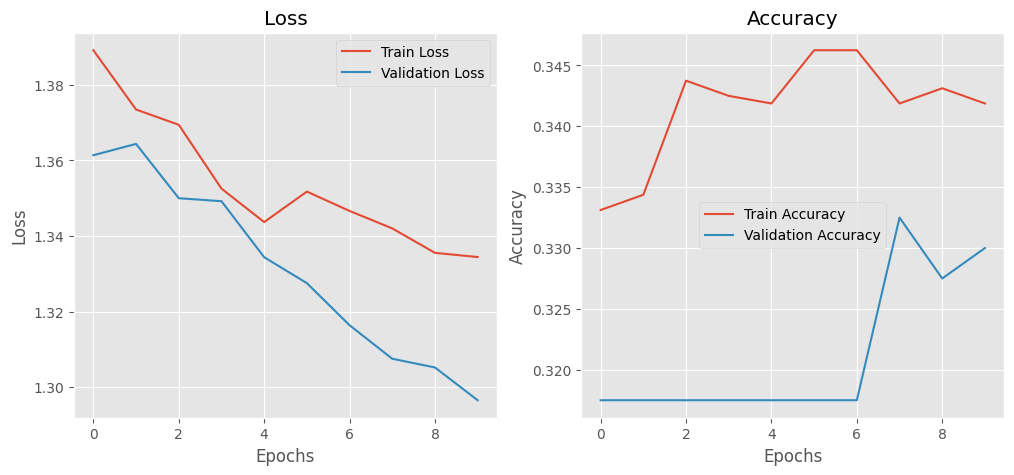

In [33]:

# Visualize training history
def plot_history(history):
    plt.style.use('ggplot')

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend() 

    plt.subplot(1, 2, 2)
    plt.plot(history['train_accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

plot_history(history)
# Save the plot
plt.savefig('training_history.png')
plt.show()